# Film vs simulation dose slice comparison

Loads a film TIFF the same way `CLEAR_RCF_processing.ipynb` does (background
subtraction -> `dose_CLEAR` conversion -> marking removal), loads the matching
simulated depth slice the same way `simulate_PDD_CLEAR.ipynb` does (note: the
sim depths array is stored back-to-front, i.e. `depths[i]` pairs with
`z_index=i` via the same `[::-1]` reversal used there), fits both with the
same SuperGaussian/2-Gaussian slice fits as `plot_dose1`, and plots them
overlaid so the shapes and magnitudes can be compared directly.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from topas2numpy import BinnedResult

from YAG_RCF_analysis import get_dose_slices
from topasToDose import getDosemap
from uniformity_fit import supergaussian1D_skewed
from flatness import sum_2gaussians_skewed

In [3]:
def get_bin_edges(dim):
    return np.linspace(0, dim.n_bins * dim.bin_width, dim.n_bins + 1)

## Film-side helpers

Copied from `CLEAR_RCF_processing.ipynb` (not in any shared module).

In [4]:
def dose_CLEAR(PV, nOD0, channel):
    if channel == 0:
        a, b, c = 4.6093, 0.1574, 4.6606
    elif channel == 1:
        a, b, c = 7.9162, 0.0418, 7.9213
    elif channel == 2:
        a, b, c = 23.5294, 0.1614, 23.2037

    OD = -np.log(PV / 65535)
    nOD = OD - nOD0
    exp_term = np.exp(-nOD)
    return (a - c * exp_term) / (exp_term - b)


def get_calibration(im_type):
    if im_type == "RCF":
        return 0.0846667  # mm/pixel


def remove_marking(film):
    h, w = film.shape
    mask = np.ones((h, w), dtype=bool)
    mask[50:-50, 50:-50] = False
    film[(mask) & (film < 30000)] = 40000
    return film

## Load helpers

In [5]:
def load_film_dosemap(tif_path, channel, OD0, crop=(25, -25, 25, -25), clean_marking=True, dose_clip=25, dose_clip_to=4):
    film = tiff.imread(tif_path)[crop[0]:crop[1], crop[2]:crop[3], channel]
    if clean_marking:
        film = remove_marking(film)
    film_flipped = np.flipud(film)

    h, w = film.shape
    pixel_calibration = get_calibration("RCF")
    x = np.arange(w) * pixel_calibration
    y = np.arange(h) * pixel_calibration

    dose = dose_CLEAR(film_flipped, OD0, channel)
    dose[dose > dose_clip] = dose_clip_to
    return x, y, dose

In [6]:
def load_sim_dosemap(dose_file, n_particles, output_filename, acChargenC, target_depth_mm):
    z_dim = BinnedResult(dose_file).dimensions[2]
    depths_mm = (get_bin_edges(z_dim)[1:] * 10)[::-1]  # same reversal as simulate_PDD_CLEAR.ipynb
    z_index = int(np.argmin(np.abs(depths_mm - target_depth_mm)))
    matched_depth = float(depths_mm[z_index])

    x, y, doseMap = getDosemap(
        dose_file, n_particles, dose_depth=matched_depth,
        outputFileName=output_filename, acChargenC=acChargenC,
        plot=False, z_index=z_index,
    )
    return x, y, doseMap, matched_depth

## Plotting

In [13]:
def plot_slice_overlay(film_slices, sim_slices, depth_mm, film_label="Film", sim_label="Simulation"):
    fig, (ax_x, ax_y) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Film vs simulation slices at depth = {depth_mm:.1f} mm")

    for ax, coord_key, slice_key, params_key, params2g_key, curve_fn, xlabel in [
        (ax_x, "new_x", "slice_row", "params_x", "params_xx", supergaussian1D_skewed, "X (mm)"),
        (ax_y, "new_y", "slice_col", "params_y", "params_yy", supergaussian1D_skewed, "Y (mm)"),
    ]:
        for slices, label, data_color, fit_color in [
            (film_slices, film_label, "tab:orange", "darkred"),
            (sim_slices, sim_label, "tab:blue", "navy"),
        ]:
            coord = slices[coord_key]
            data = slices[slice_key]
            ax.plot(coord, data, "o", color=data_color, alpha=0.5, markersize=3, label=f"{label} data")

            params = slices[params_key]
            fit_curve = curve_fn(coord, *params)
            ax.plot(coord, fit_curve, "-", color=fit_color, linewidth=1.8,
                     label=f"{label} SuperGaussian fit (P={params[3]:.2f})")

            params_2g = slices[params2g_key]
            if params_2g is not None:
                ax.plot(coord, sum_2gaussians_skewed(coord, *params_2g), "--", color=fit_color, linewidth=1.2,
                         label=f"{label} 2-Gaussian fit")

        ax.set_xlabel(xlabel)
        ax.set_ylabel("Dose (Gy)")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    return fig

In [ ]:
def plot_transverse_pct_diff(film_slices, sim_slices, depth_mm, film_label="Film"):
    """% difference of film from simulation at every point along the X and Y transverse axes,
    using the fitted SuperGaussian curves evaluated on a shared coordinate grid (film and sim
    have different pixel grids, so a direct point-by-point comparison needs a common axis)."""
    fig, (ax_x, ax_y) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{film_label} % difference from simulation at depth = {depth_mm:.1f} mm")

    for ax, coord_key, params_key, xlabel in [
        (ax_x, "new_x", "params_x", "X (mm)"),
        (ax_y, "new_y", "params_y", "Y (mm)"),
    ]:
        film_coord = film_slices[coord_key]
        sim_coord = sim_slices[coord_key]
        lo = max(film_coord.min(), sim_coord.min())
        hi = min(film_coord.max(), sim_coord.max())
        coord = np.linspace(lo, hi, 200)

        film_curve = supergaussian1D_skewed(coord, *film_slices[params_key])
        sim_curve = supergaussian1D_skewed(coord, *sim_slices[params_key])
        pct_diff = (film_curve - sim_curve) / sim_curve * 100

        ax.plot(coord, pct_diff, "-", color="tab:green", linewidth=1.8)
        ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Film % difference from sim")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    return fig

## Config

Edit `film_filename` / `film_depth_mm` (and the sim config below) to compare a
different film or depth.

In [51]:
# ---- film config (mirrors CLEAR_RCF_processing.ipynb) ----
channel = 0
film_dir = "CLEAR_experiments/May2026/scatterer_15-05_2026_21h/"
bkgd1 = tiff.imread(film_dir + "G_025.tif")[50:-25, 25:-25, channel]
bkgd2 = tiff.imread(film_dir + "G_026.tif")[50:-25, 25:-25, channel]
OD0 = -np.log(np.mean([bkgd1, bkgd2]) / 65535)

film_filename = "G_001"
film_depth_mm = 20.0  # known depth for this film, e.g. from depth_map in PDD_CLEAR.ipynb

In [57]:
# ---- sim config (mirrors simulate_PDD_CLEAR.ipynb) ----
dose_file = "CLEAR_experiments/May2026/DoseAtTank256_CLEAR_dual_scatterer_0515_small_col_YAG_875_full.csv"
output_filename = "CLEAR_dual_scatterer_0515_small_YAG_875_full"
chargenC = 22.9 #at THz1
n_particles = int(3e6)

## Load both and plot

In [54]:
fx, fy, film_dose = load_film_dosemap(film_dir + film_filename + ".tif", channel, OD0)
sx, sy, sim_dose, matched_depth = load_sim_dosemap(dose_file, n_particles, output_filename, chargenC, film_depth_mm)

print(f"Film {film_filename} (depth {film_depth_mm} mm) vs sim z-slice at matched depth {matched_depth:.1f} mm")

Film G_001 (depth 20.0 mm) vs sim z-slice at matched depth 20.0 mm


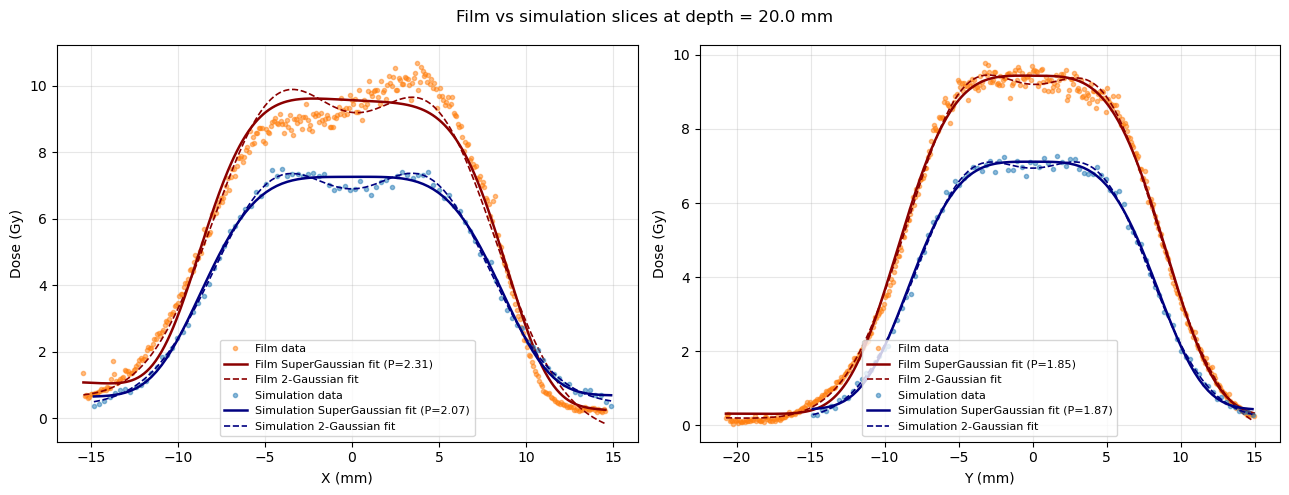

In [44]:
film_slices = get_dose_slices(film_dose, fx, fy, strip_width=2)
sim_slices = get_dose_slices(sim_dose, sx, sy, strip_width=2)

fig = plot_slice_overlay(film_slices, sim_slices, matched_depth)
plt.show()

In [58]:
def integrated_dose(dose_map, x, y):
    """Area-weighted total dose (Gy*mm^2), so film and sim (different pixel sizes) are comparable."""
    pixel_area_mm2 = np.mean(np.diff(x)) * np.mean(np.diff(y))
    return np.sum(dose_map) * pixel_area_mm2


film_integrated = integrated_dose(film_dose, fx, fy)
sim_integrated = integrated_dose(sim_dose, sx, sy)

print(f"Film integrated dose:      {film_integrated:10.2f} Gy*mm^2")
print(f"Simulated integrated dose: {sim_integrated:10.2f} Gy*mm^2")
print(f"Sim / film ratio:          {sim_integrated / film_integrated:10.3f}")


Film integrated dose:         2369.00 Gy*mm^2
Simulated integrated dose:    3945.22 Gy*mm^2
Sim / film ratio:               1.665


## All uncollimated films vs matched sim depth

`depth_map = [45, 134, 163, 222, 281]` (minus 25, per the same convention as
`PDD_CLEAR.ipynb`) gives the depth for each block of 4 films. Within a block,
`repeat_in_block` 1-3 are uncollimated and 4 is collimated — the simulation
here is uncollimated only, so films 4/8/12/16/20 are skipped.

In [47]:
depth_map = [45, 104, 163, 222, 281]

film_specs = []
for block, raw_depth in enumerate(depth_map):
    depth = raw_depth - 25
    for rep in [1, 2, 3]:  # skip rep 4: collimated, not simulated here
        film_num = block * 4 + rep
        film_specs.append((f"G_{film_num:03d}", depth))

film_specs

[('G_001', 20),
 ('G_002', 20),
 ('G_003', 20),
 ('G_005', 79),
 ('G_006', 79),
 ('G_007', 79),
 ('G_009', 138),
 ('G_010', 138),
 ('G_011', 138),
 ('G_013', 197),
 ('G_014', 197),
 ('G_015', 197),
 ('G_017', 256),
 ('G_018', 256),
 ('G_019', 256)]

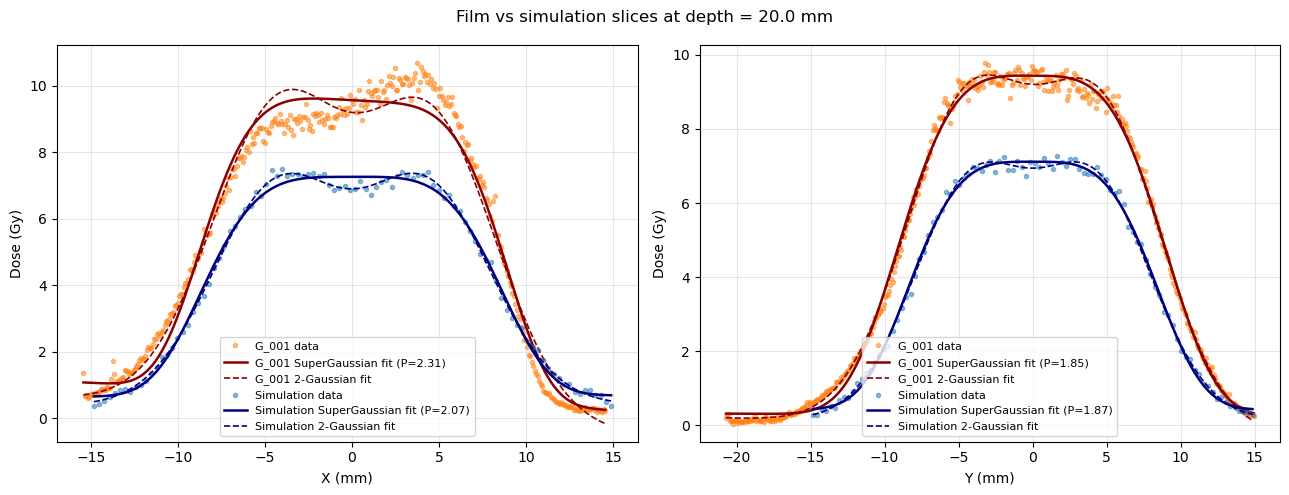

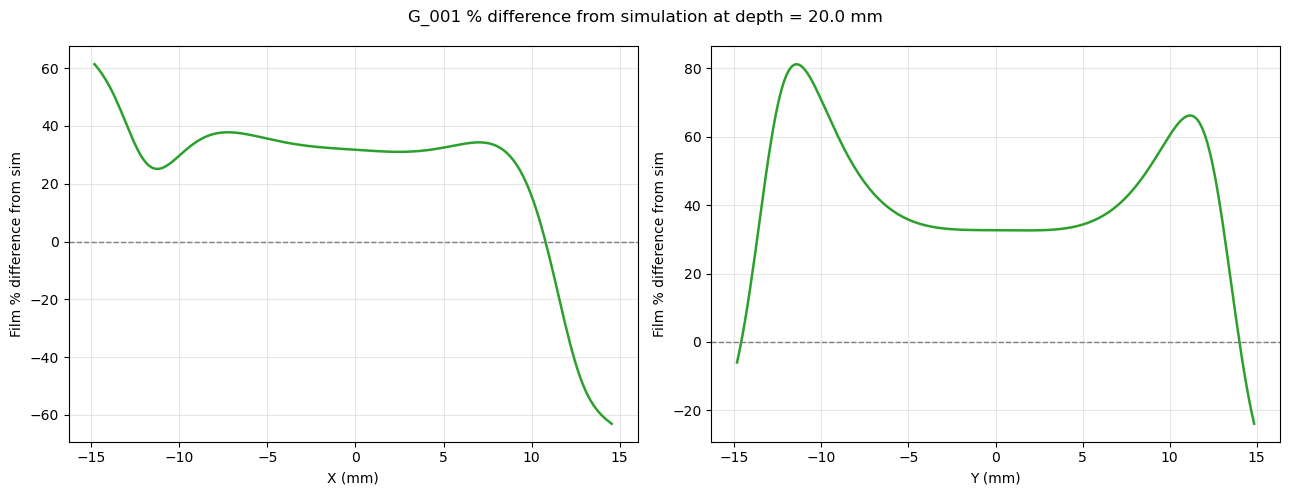

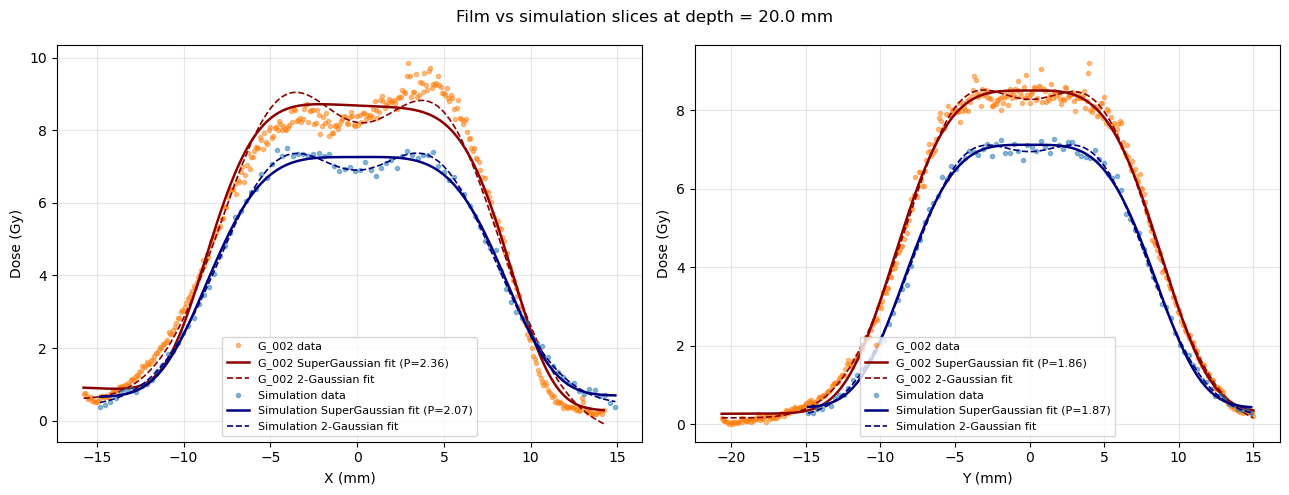

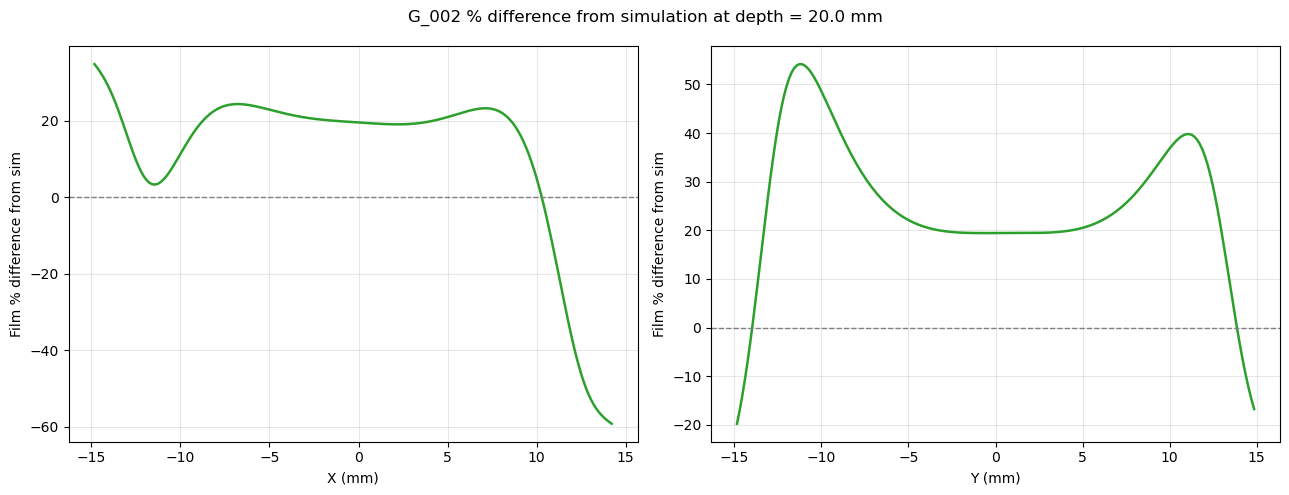

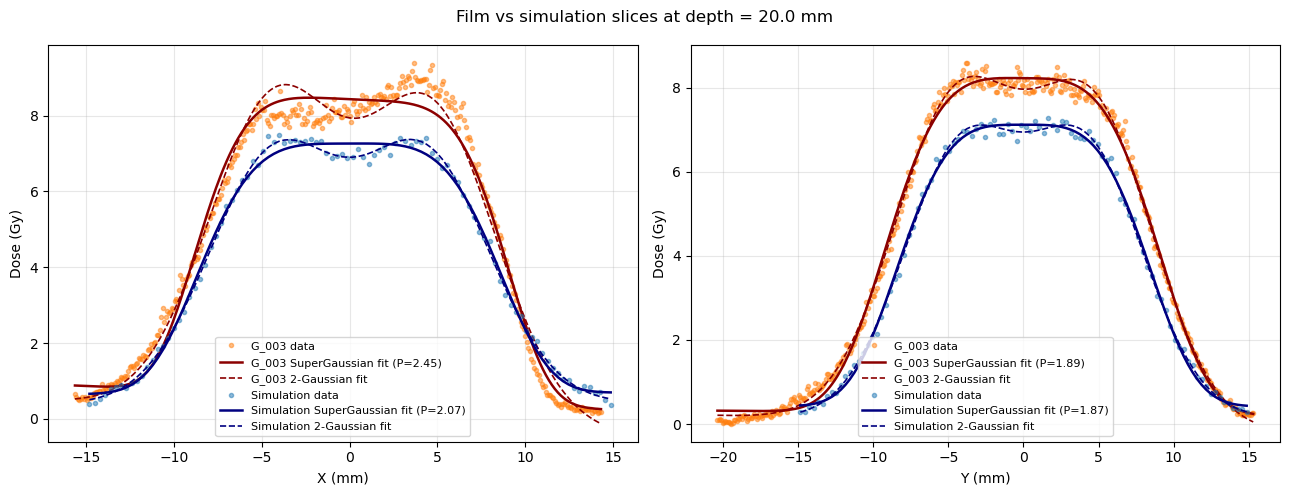

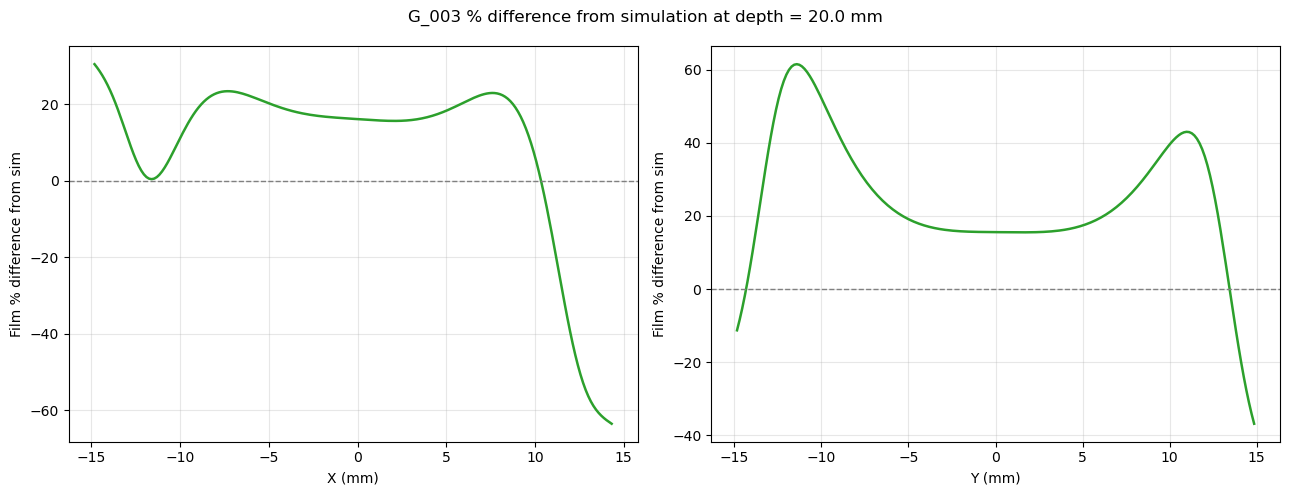

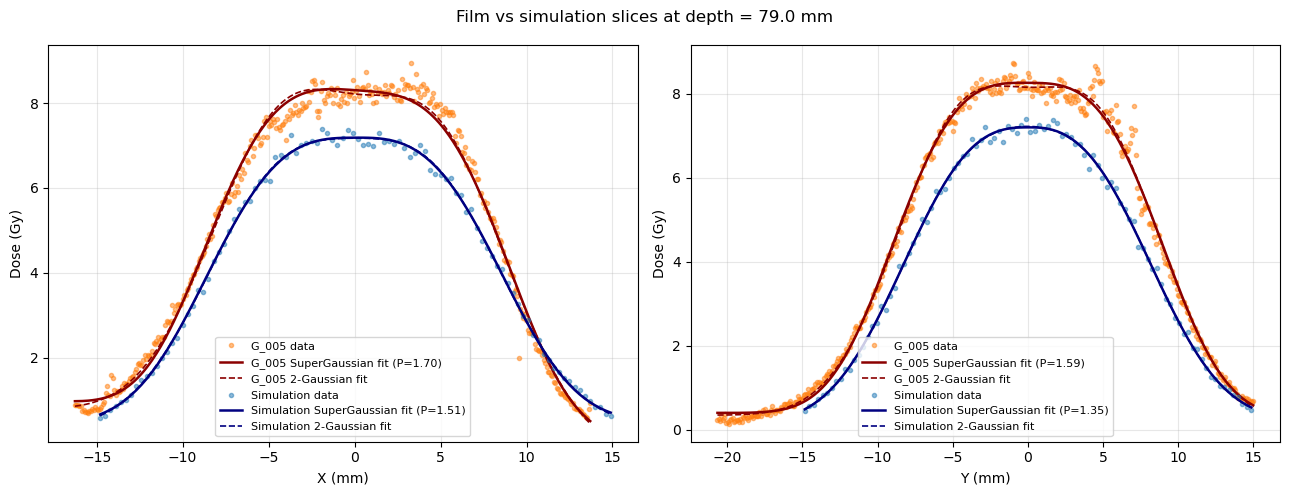

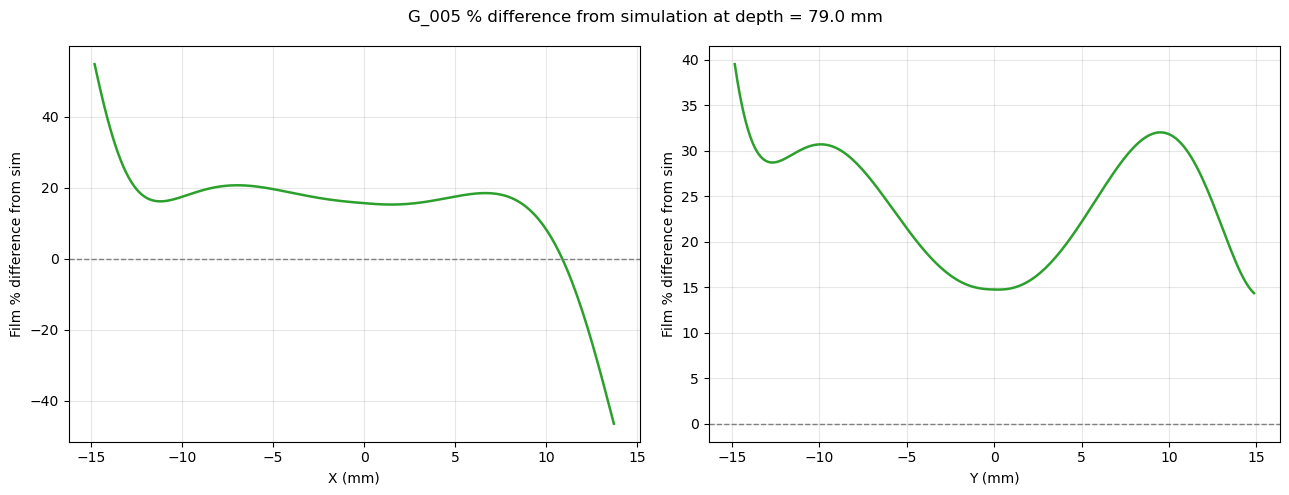

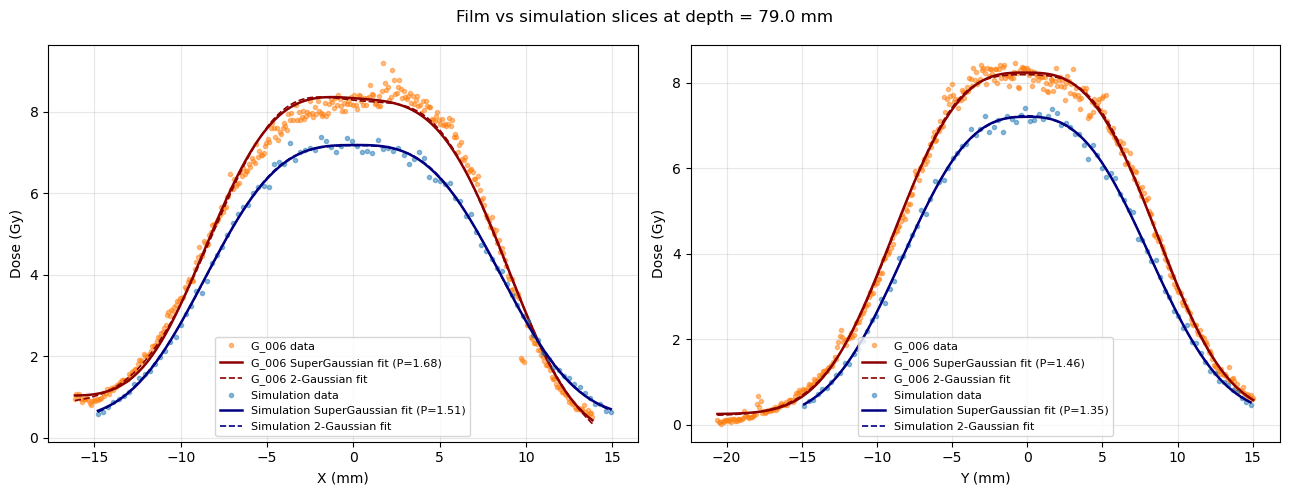

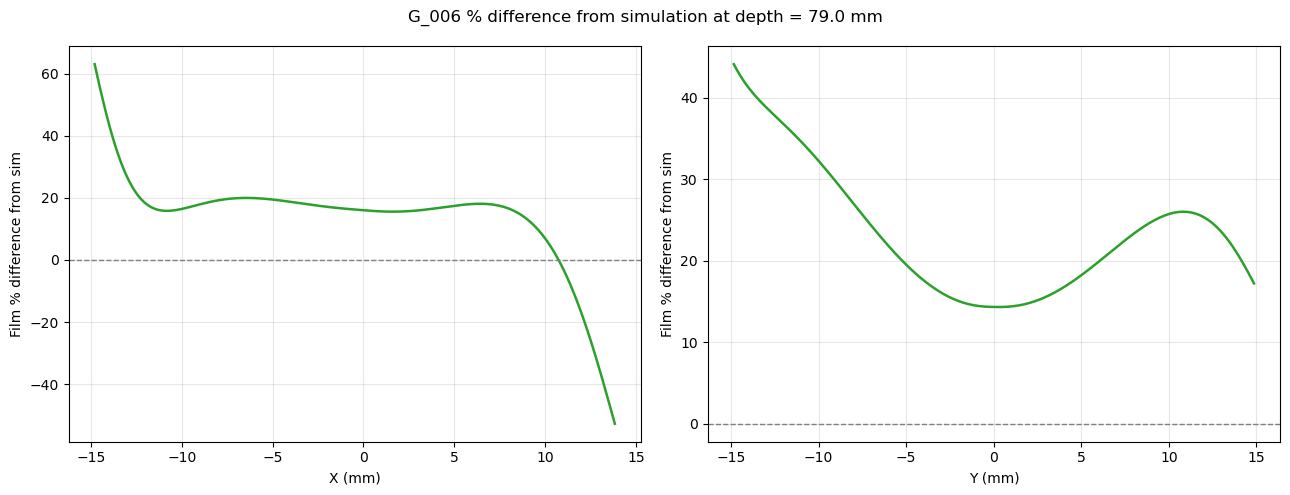

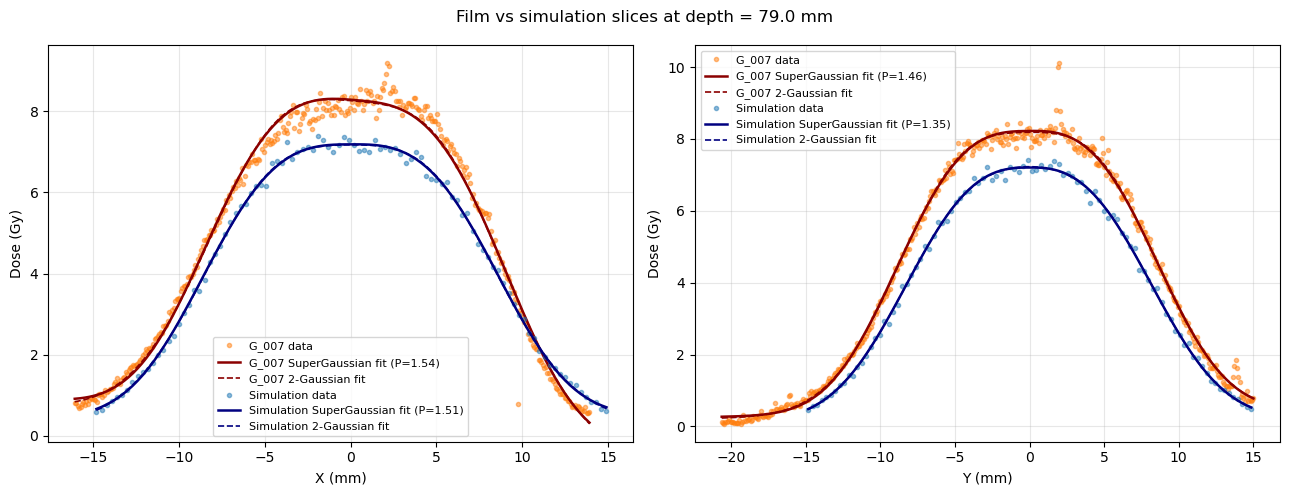

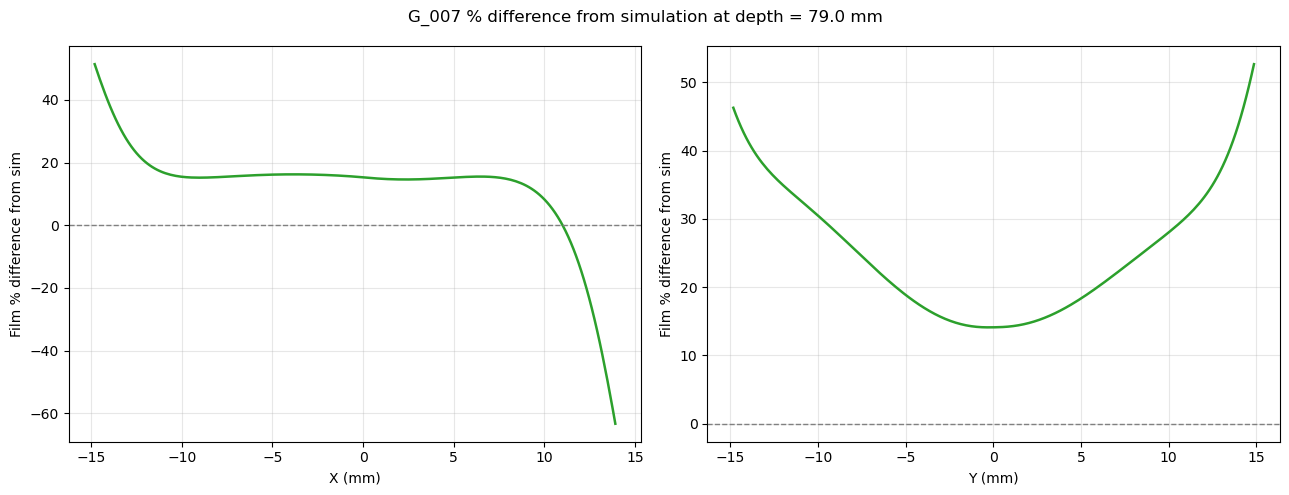

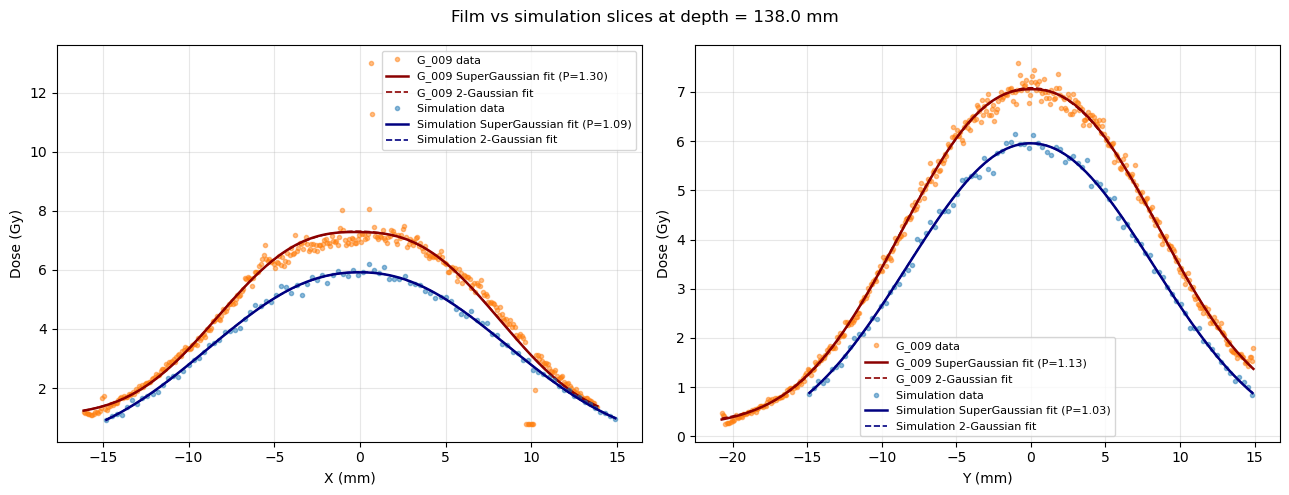

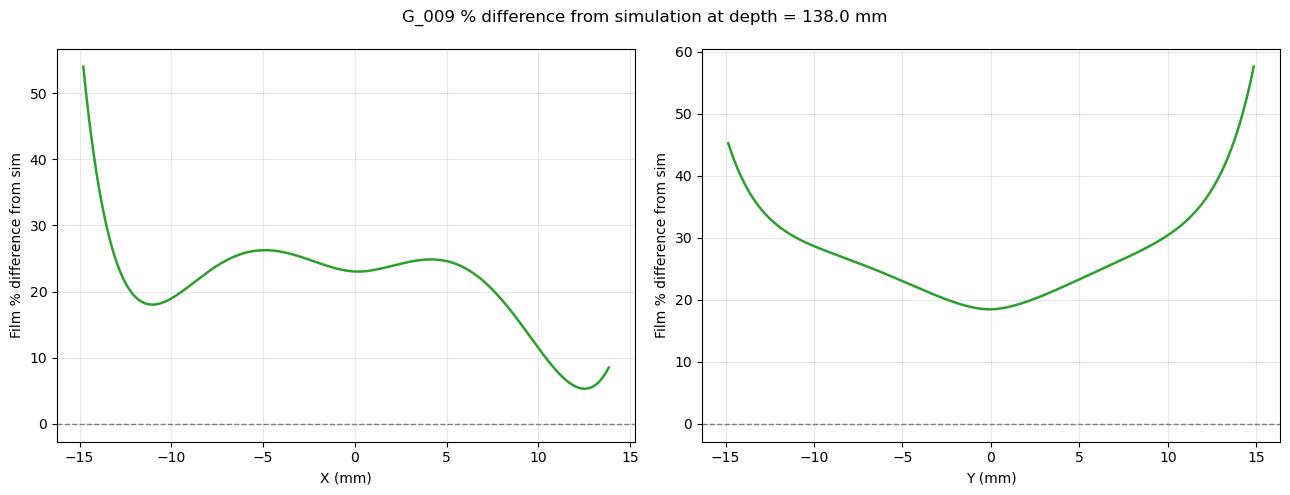

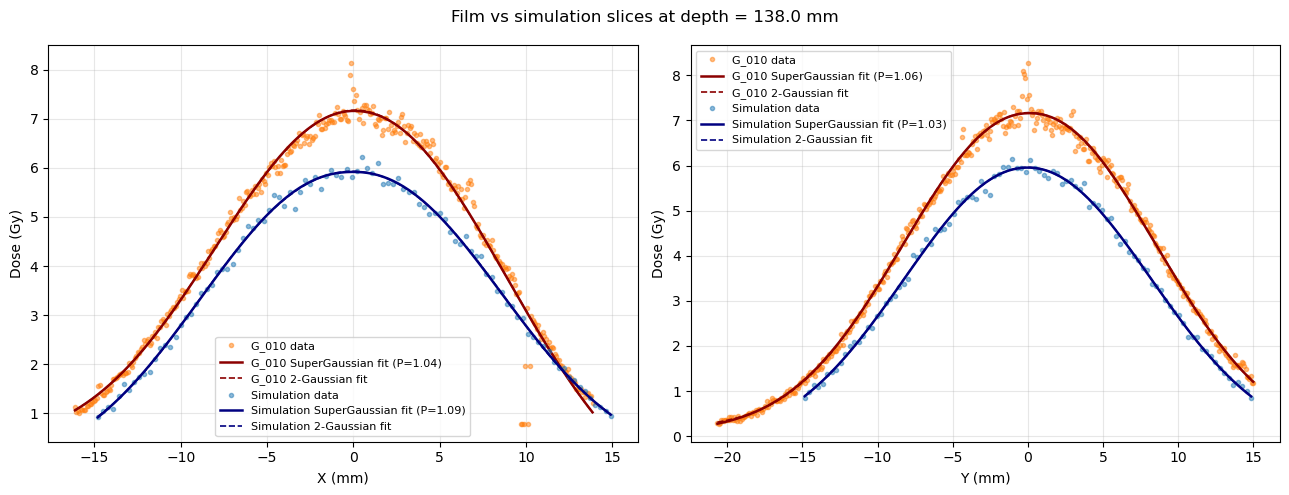

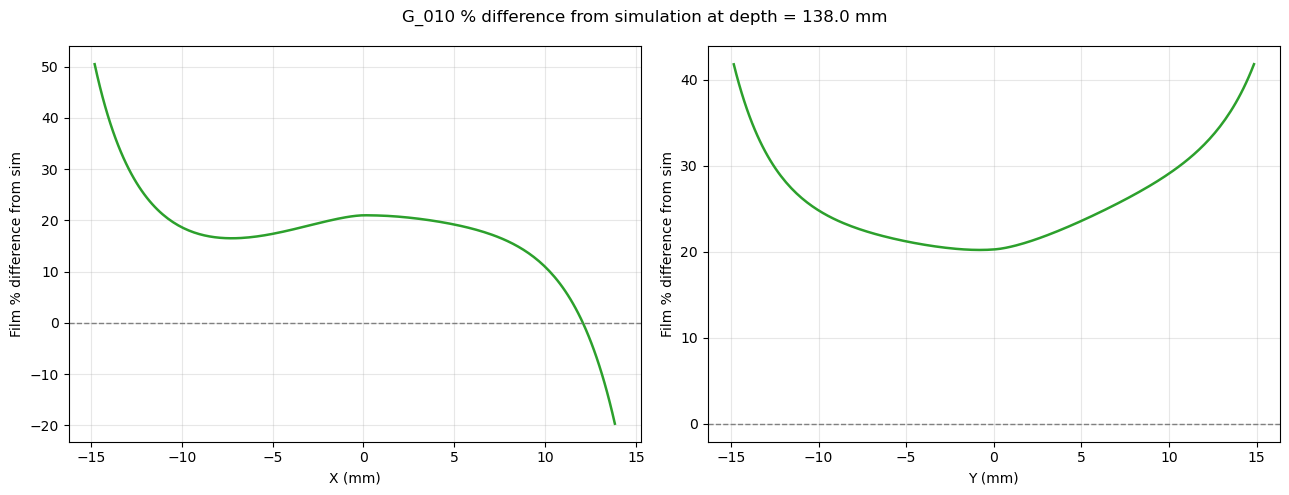

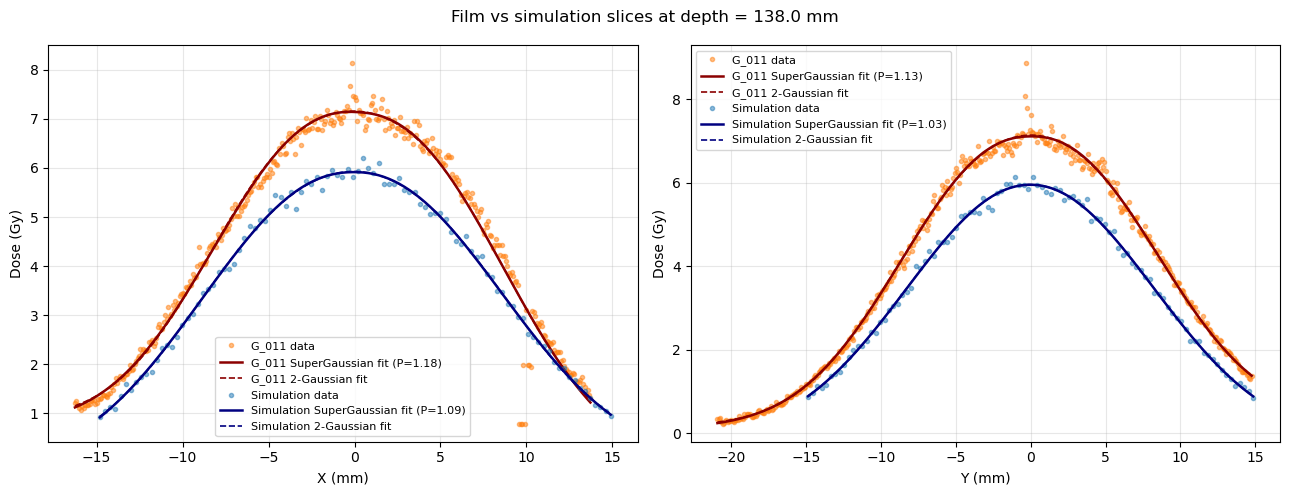

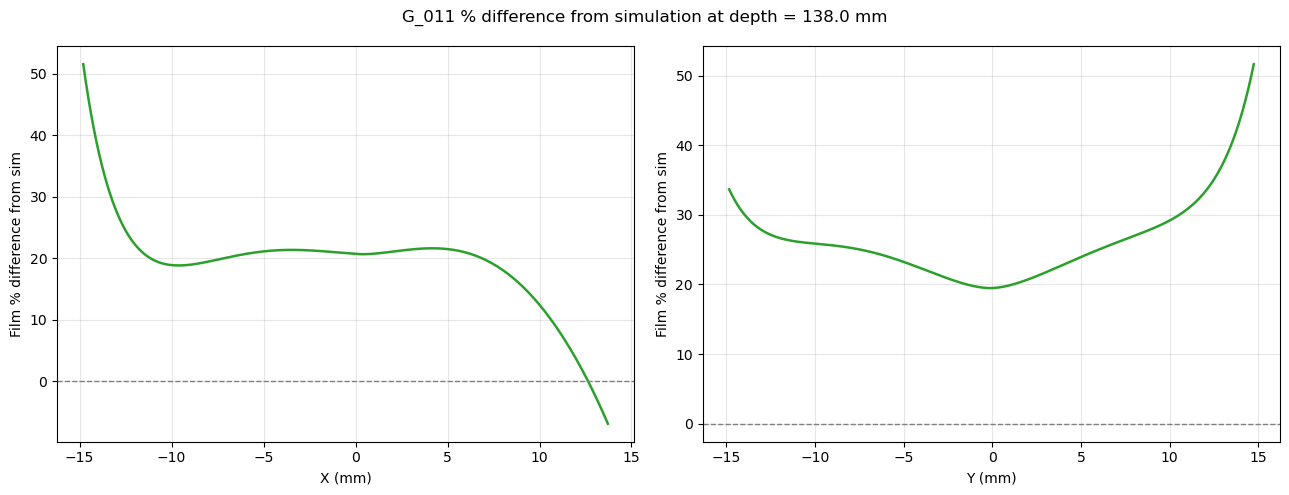

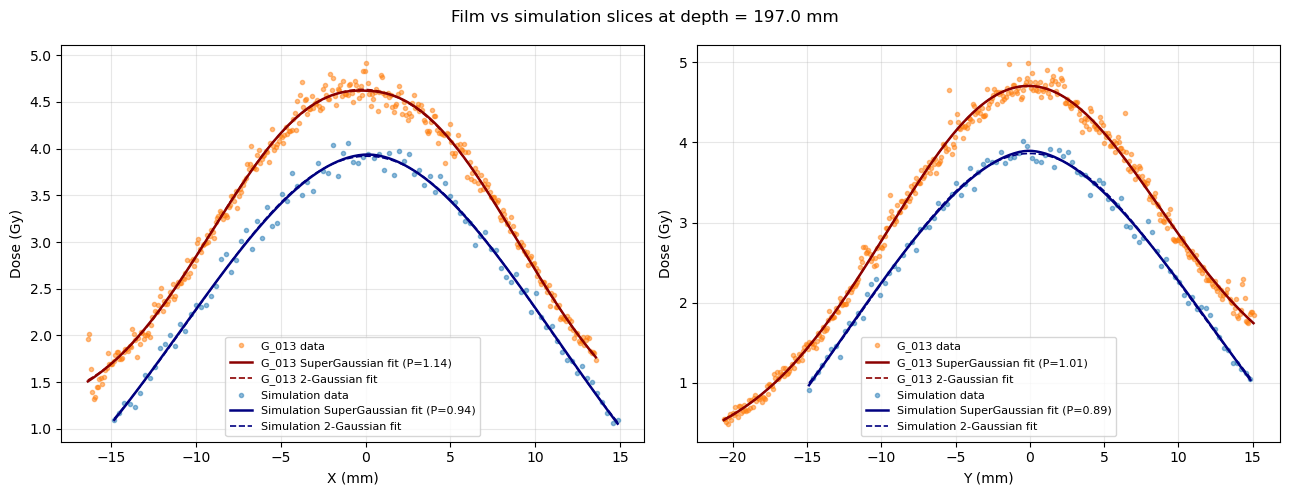

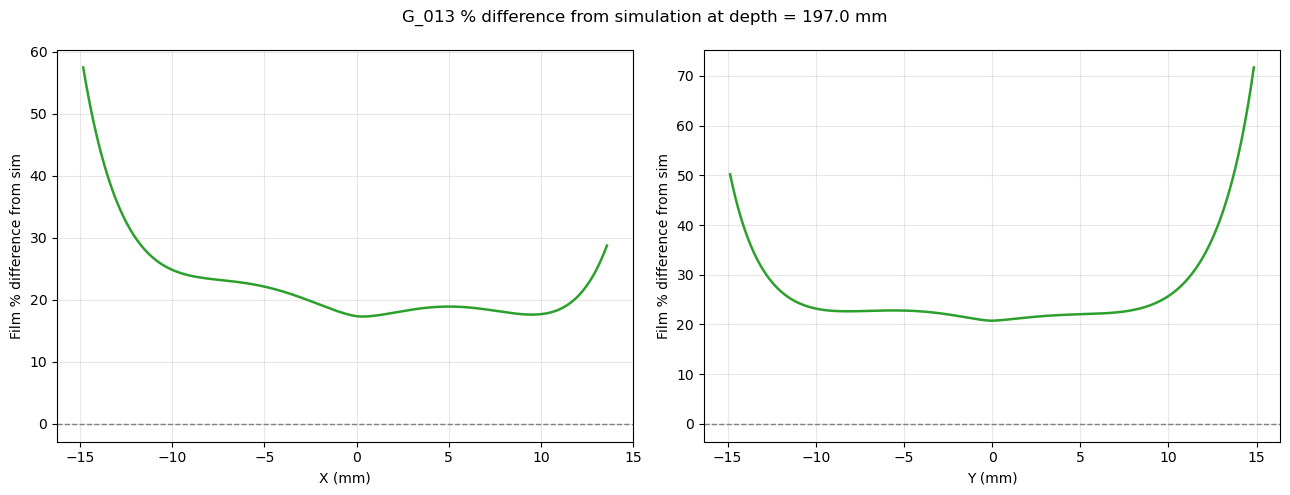

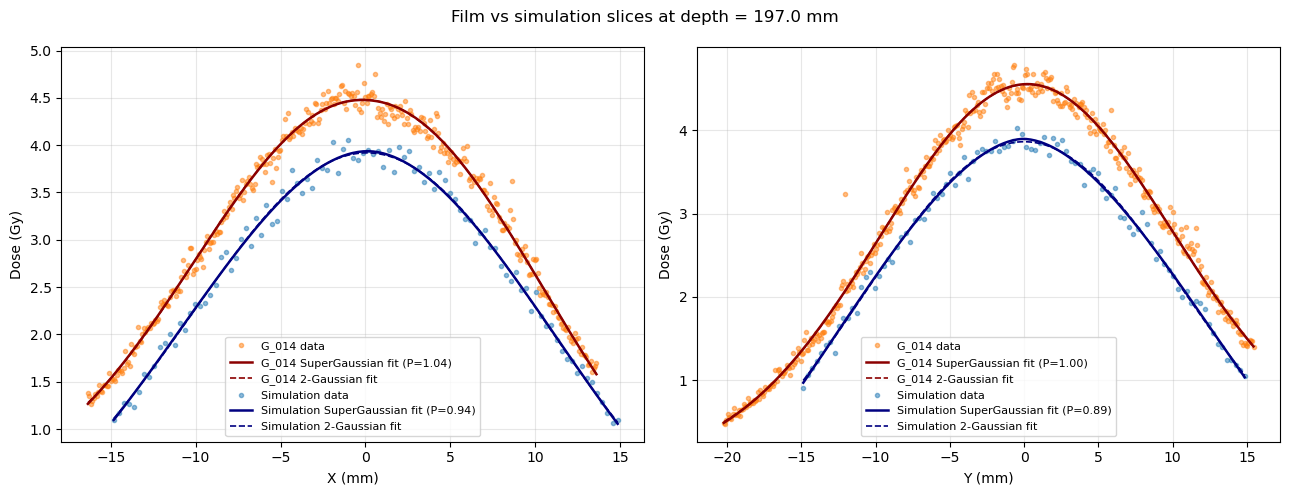

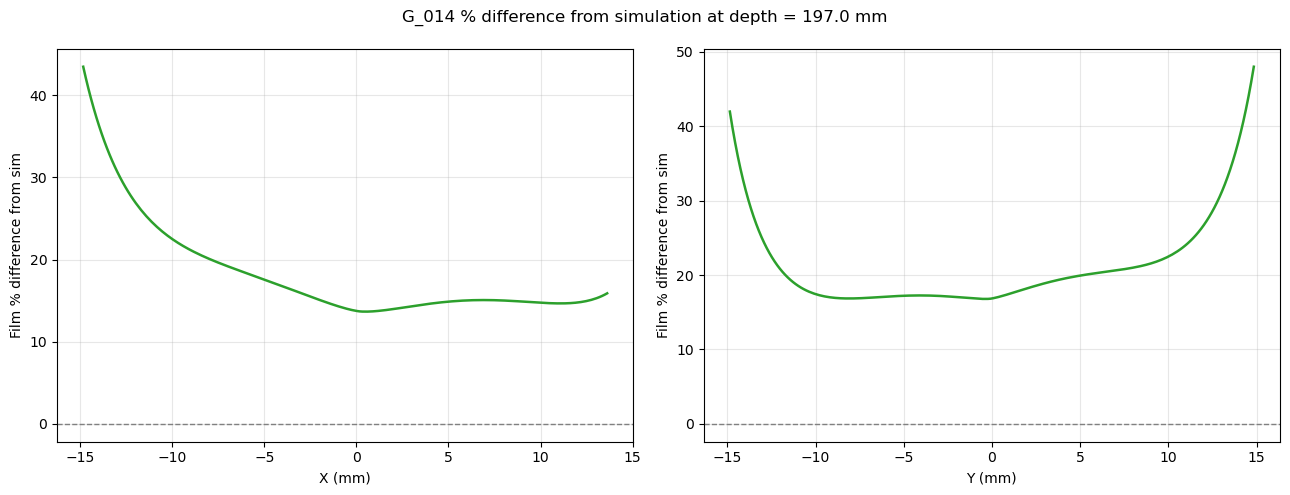

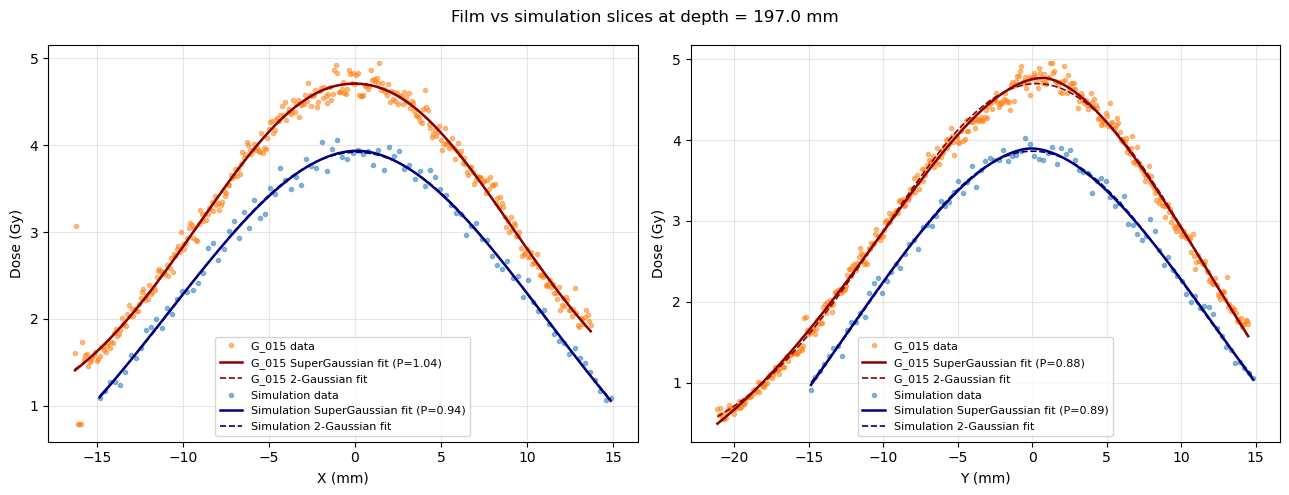

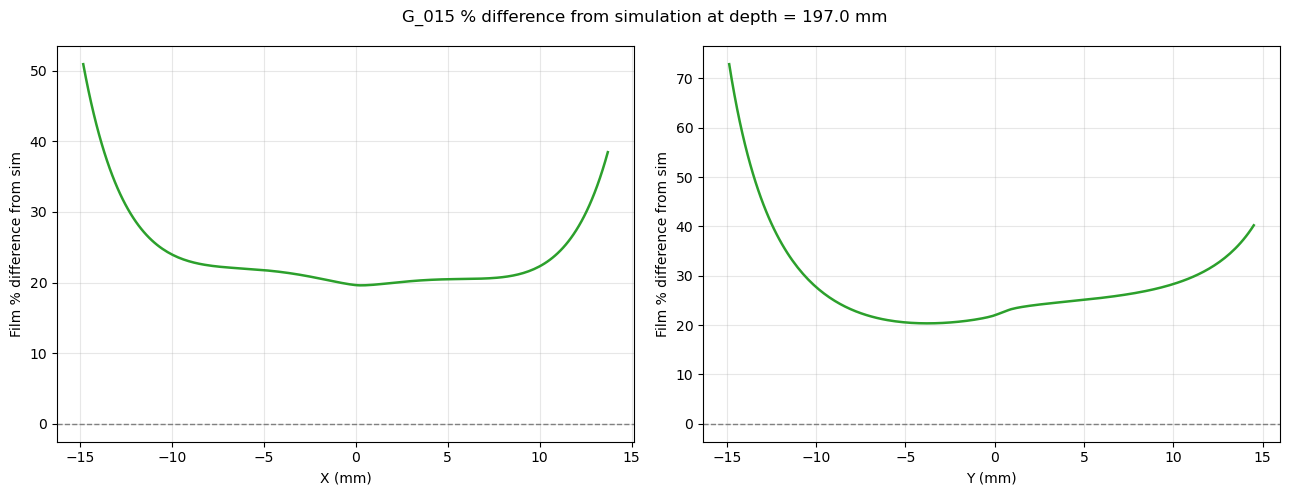

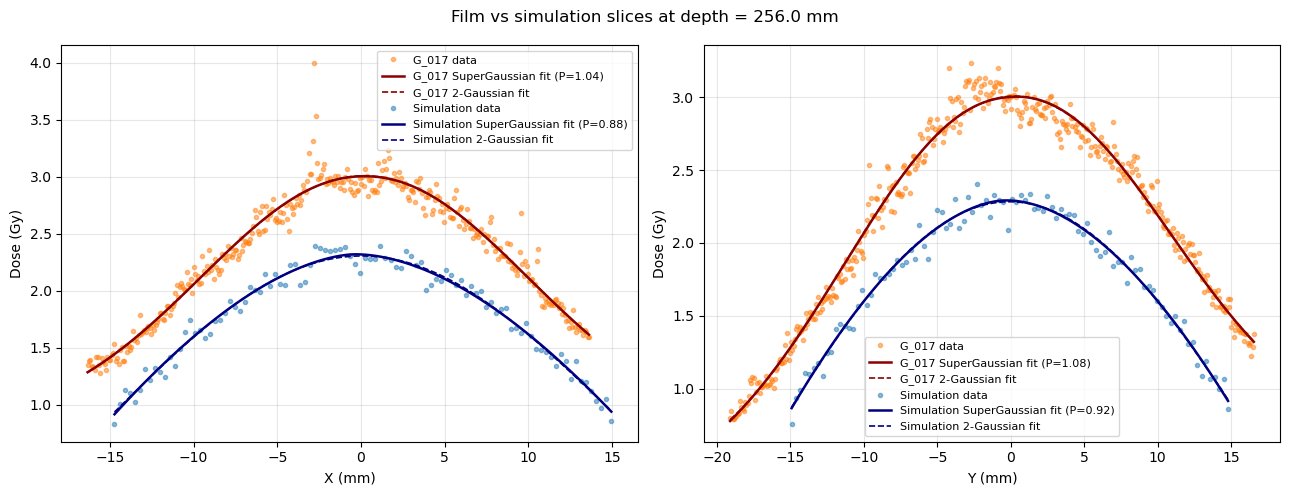

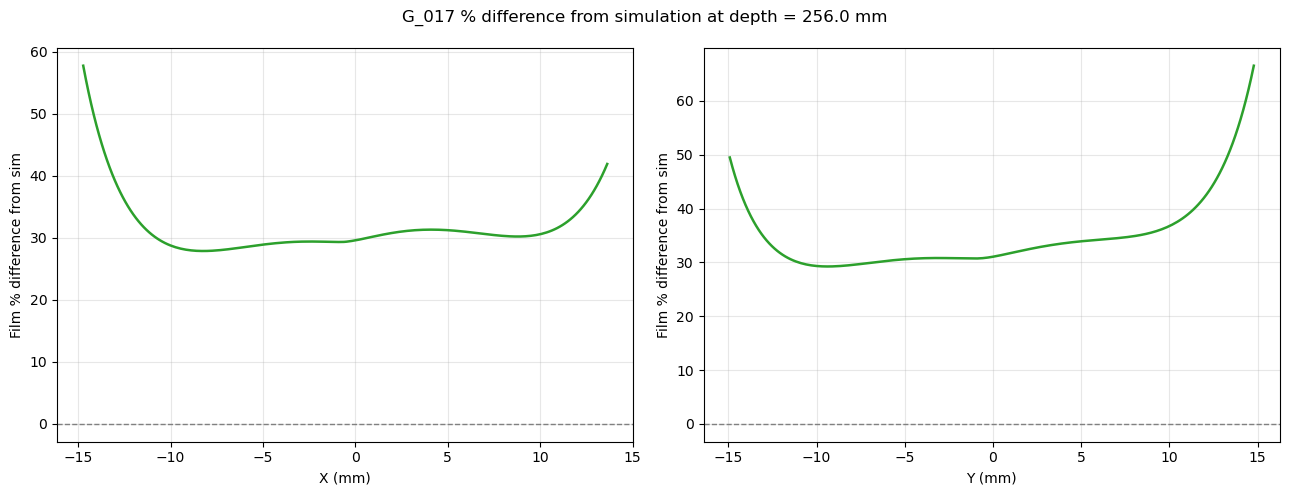

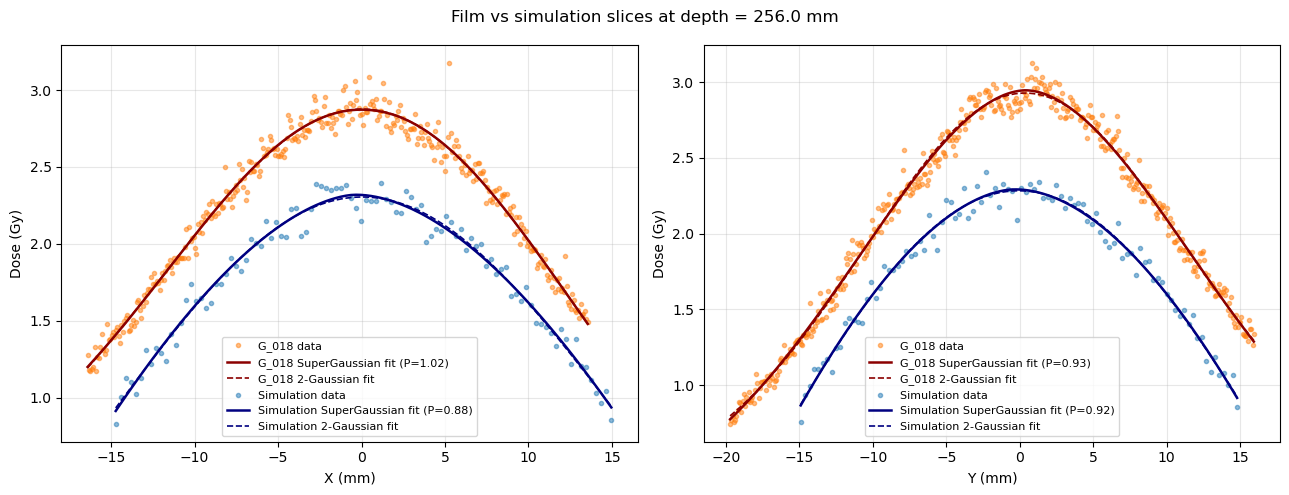

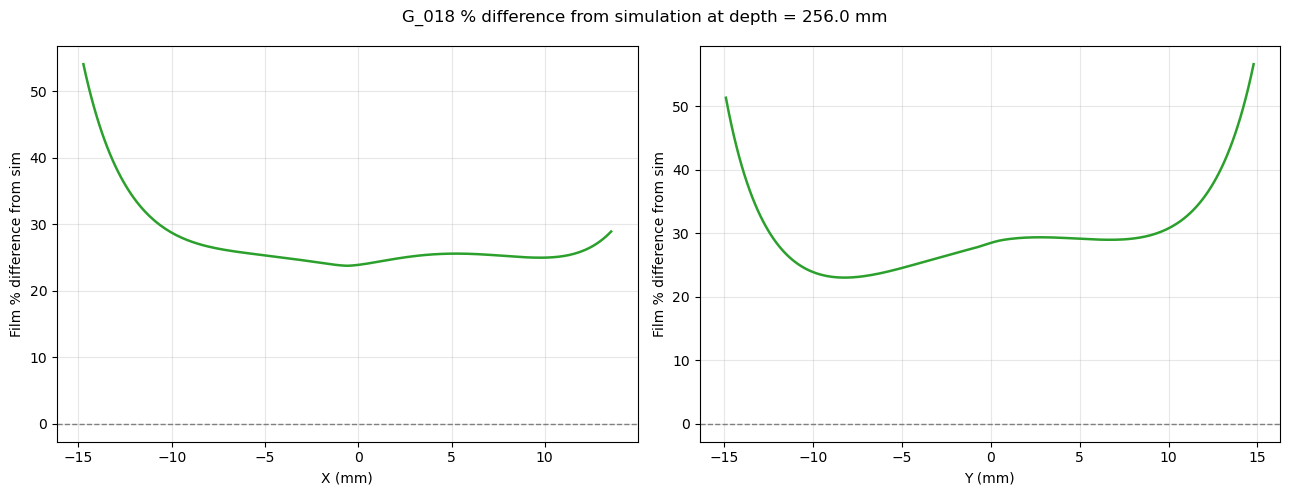

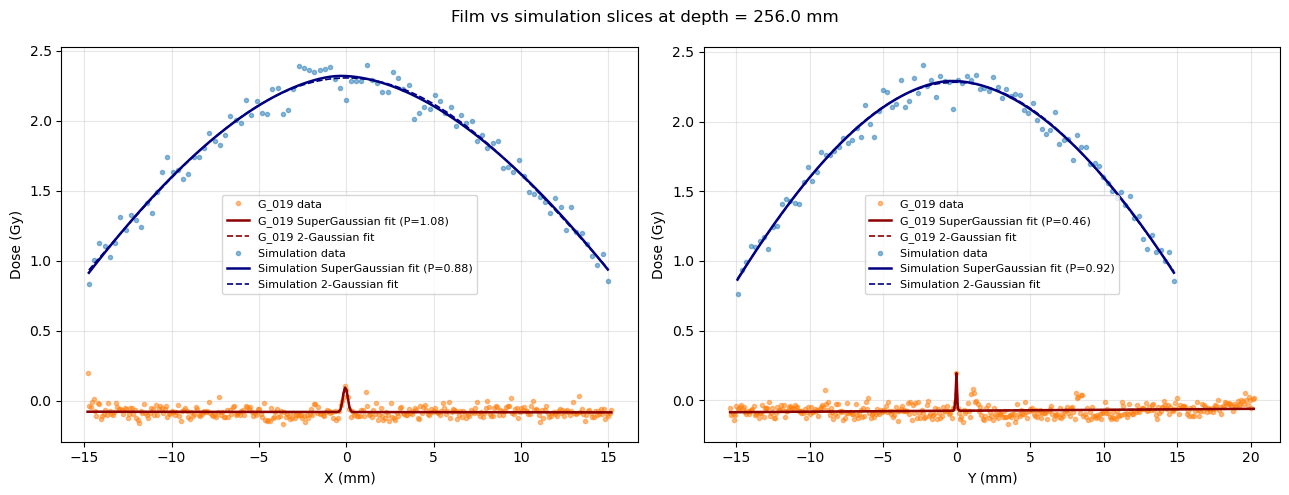

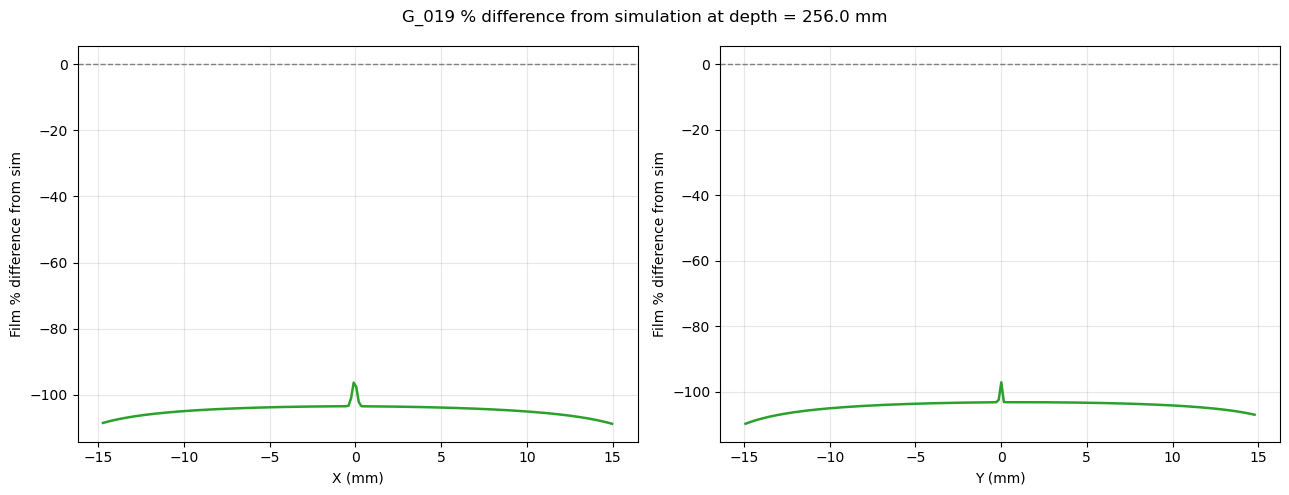

In [48]:
figs = {}
for film_filename, depth_mm in film_specs:
    fx, fy, film_dose = load_film_dosemap(film_dir + film_filename + ".tif", channel, OD0)
    sx, sy, sim_dose, matched_depth = load_sim_dosemap(
        dose_file, n_particles, output_filename, chargenC, depth_mm
    )

    film_slices = get_dose_slices(film_dose, fx, fy, strip_width=2)
    sim_slices = get_dose_slices(sim_dose, sx, sy, strip_width=2)

    fig = plot_slice_overlay(film_slices, sim_slices, matched_depth, film_label=film_filename)
    figs[film_filename] = fig
    plt.show()

    diff_fig = plot_transverse_pct_diff(film_slices, sim_slices, matched_depth, film_label=film_filename)
    plt.show()

G_001  depth=  20.0 mm  film=   2799.53  sim=   1895.78  ratio=0.677
G_002  depth=  20.0 mm  film=   2517.03  sim=   1895.78  ratio=0.753
G_003  depth=  20.0 mm  film=   2490.17  sim=   1895.78  ratio=0.761
G_005  depth= 109.0 mm  film=   2683.60  sim=   1996.43  ratio=0.744
G_006  depth= 109.0 mm  film=   2641.21  sim=   1996.43  ratio=0.756
G_007  depth= 109.0 mm  film=   2633.68  sim=   1996.43  ratio=0.758
G_009  depth= 138.0 mm  film=   2692.60  sim=   1920.99  ratio=0.713
G_010  depth= 138.0 mm  film=   2630.36  sim=   1920.99  ratio=0.730
G_011  depth= 138.0 mm  film=   2641.90  sim=   1920.99  ratio=0.727
G_013  depth= 197.0 mm  film=   2320.23  sim=   1606.47  ratio=0.692
G_014  depth= 197.0 mm  film=   2227.89  sim=   1606.47  ratio=0.721
G_015  depth= 197.0 mm  film=   2337.76  sim=   1606.47  ratio=0.687
G_017  depth= 256.0 mm  film=   1844.50  sim=   1162.30  ratio=0.630
G_018  depth= 256.0 mm  film=   1781.06  sim=   1162.30  ratio=0.653
G_019  depth= 256.0 mm  film=    -

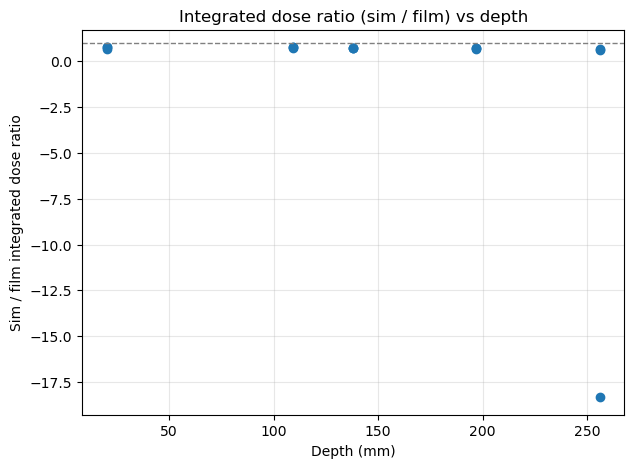

In [23]:
integrated_rows = []
for film_filename, depth_mm in film_specs:
    fx, fy, film_dose = load_film_dosemap(film_dir + film_filename + ".tif", channel, OD0)
    sx, sy, sim_dose, matched_depth = load_sim_dosemap(
        dose_file, n_particles, output_filename, chargenC, depth_mm
    )

    film_integrated = integrated_dose(film_dose, fx, fy)
    sim_integrated = integrated_dose(sim_dose, sx, sy)

    integrated_rows.append({
        "film": film_filename,
        "depth_mm": matched_depth,
        "film_integrated": film_integrated,
        "sim_integrated": sim_integrated,
        "sim_over_film": sim_integrated / film_integrated,
    })

for row in integrated_rows:
    print(f"{row['film']}  depth={row['depth_mm']:6.1f} mm  "
          f"film={row['film_integrated']:10.2f}  sim={row['sim_integrated']:10.2f}  "
          f"ratio={row['sim_over_film']:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([r["depth_mm"] for r in integrated_rows], [r["sim_over_film"] for r in integrated_rows],
        "o", markersize=6)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Depth (mm)")
ax.set_ylabel("Sim / film integrated dose ratio")
ax.set_title("Integrated dose ratio (sim / film) vs depth")
ax.grid(alpha=0.3)
plt.show()


## Collimated films vs matched sim depth

Rep 4 of each block in `depth_map` is the collimated film, and the sim config
above (`dose_file`, `output_filename`) already points at the collimated
(`large_col`) dose file, so these compare directly. The 20th Aug run also has
two extra collimated repeats: film 21 (depth 45) and film 22 (depth 134).

In [55]:
collimated_film_specs = [(f"G_{block * 4 + 4:03d}", raw_depth - 25) for block, raw_depth in enumerate(depth_map)]
collimated_film_specs += [("G_021", depth_map[4] - 25), ("G_022", depth_map[3] - 25)]

collimated_film_specs

[('G_004', 20),
 ('G_008', 79),
 ('G_012', 138),
 ('G_016', 197),
 ('G_020', 256),
 ('G_021', 256),
 ('G_022', 197)]

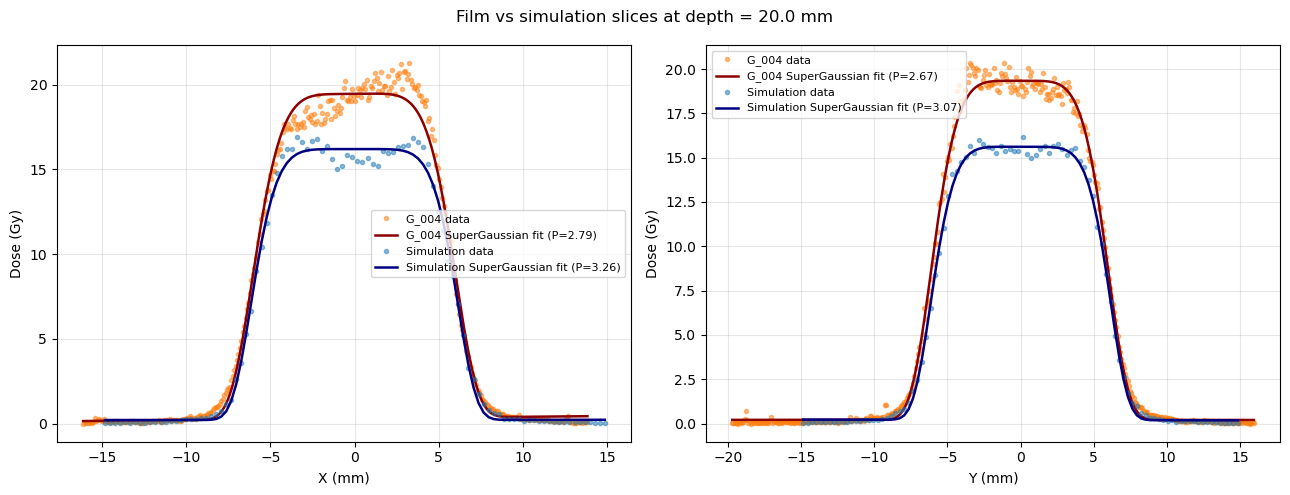

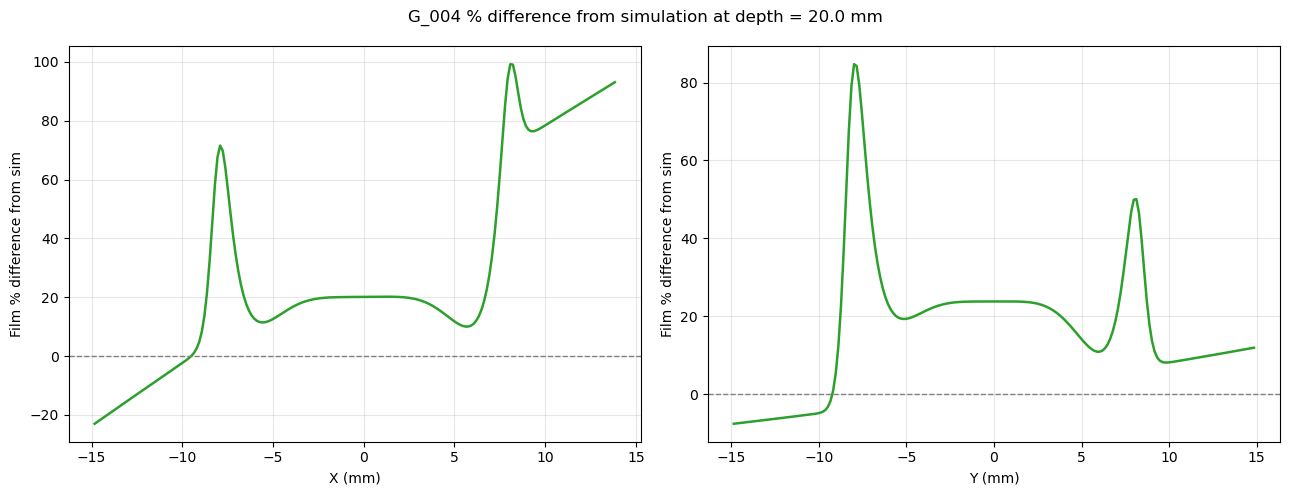

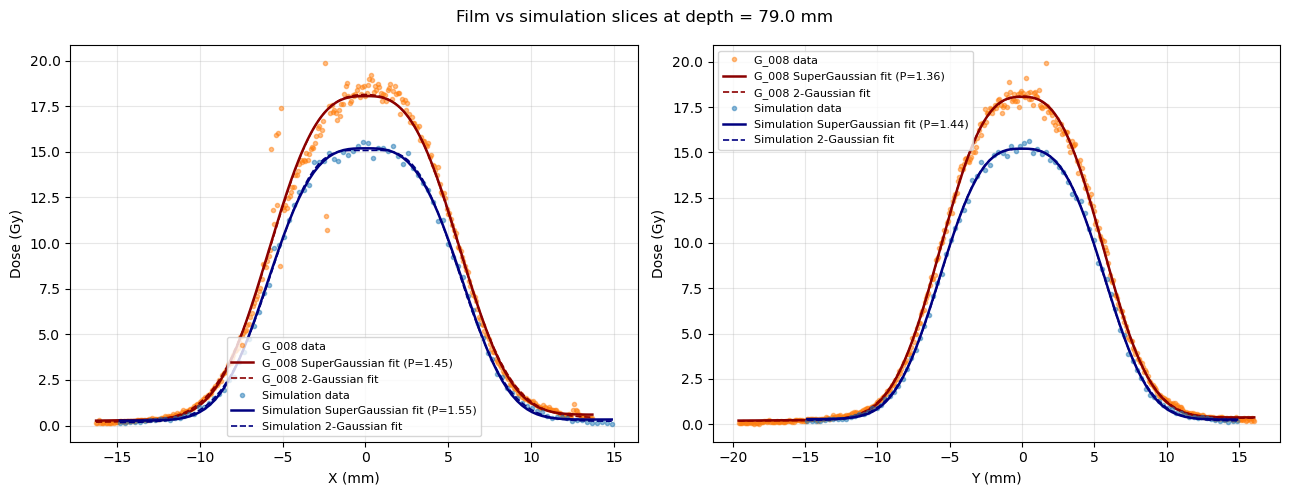

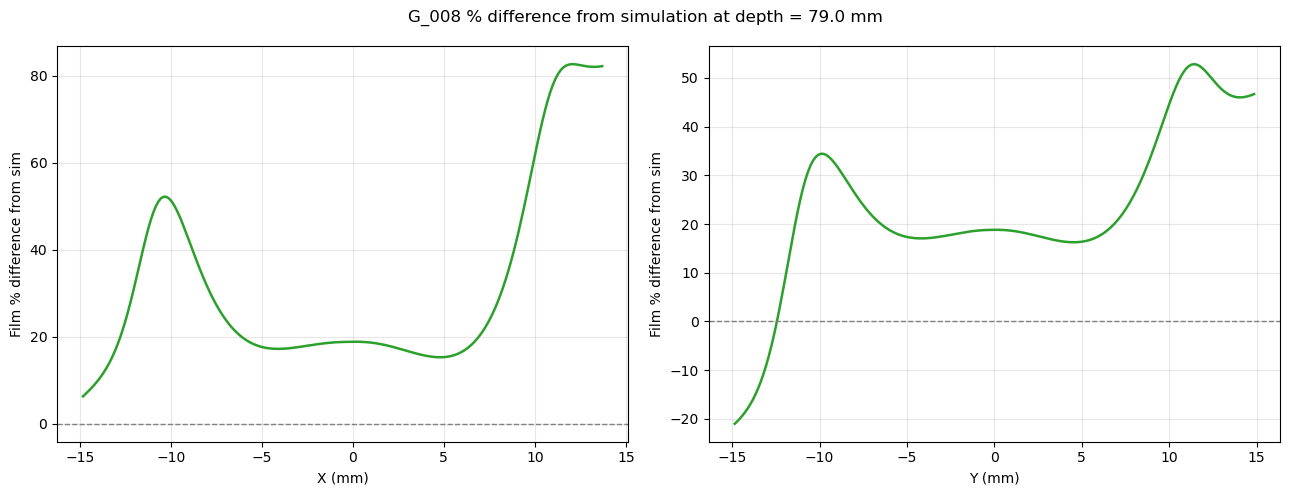

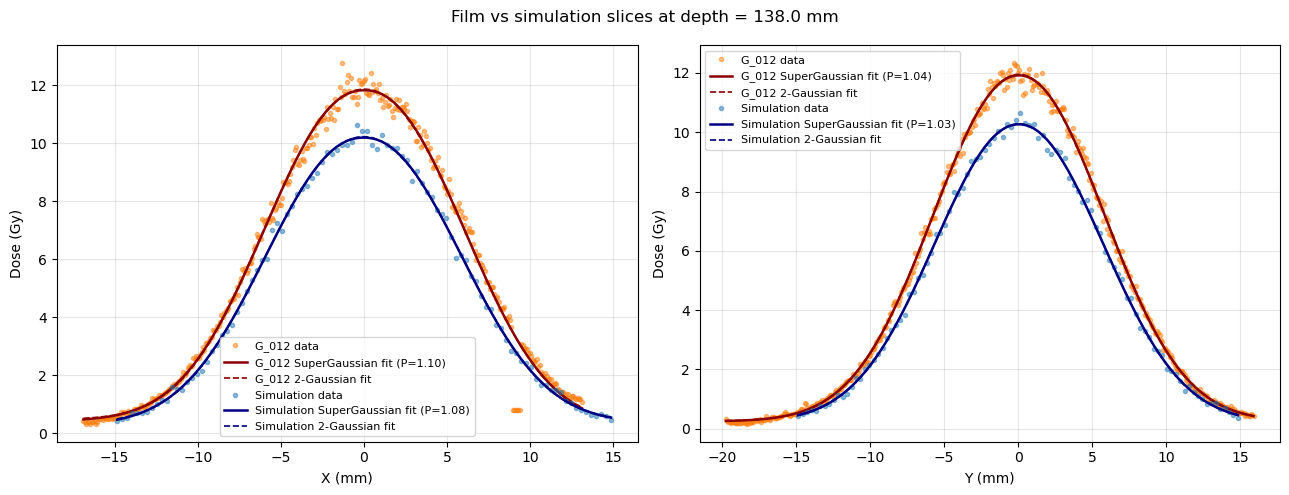

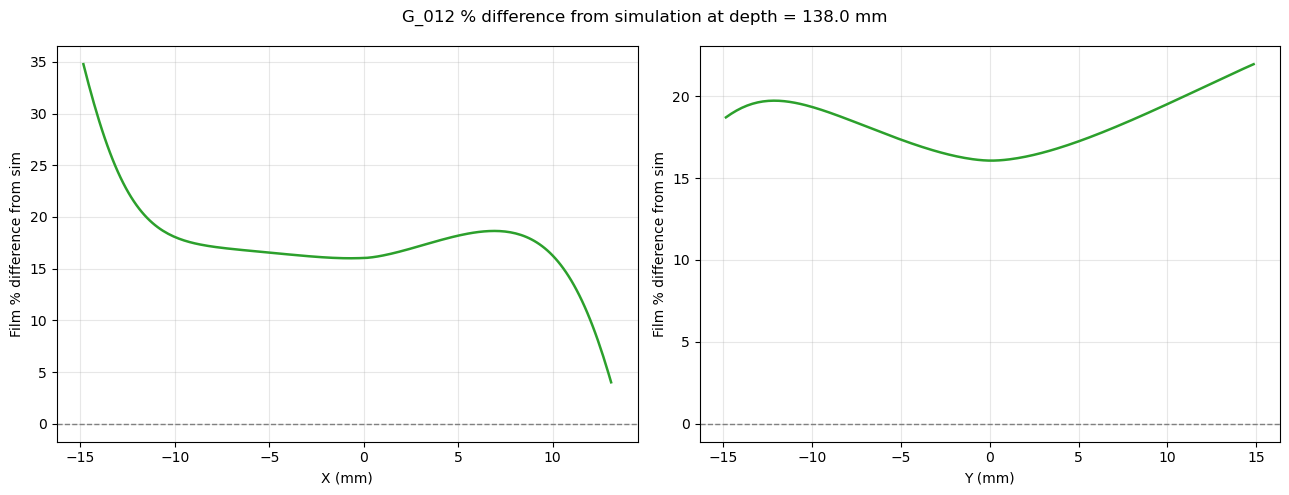

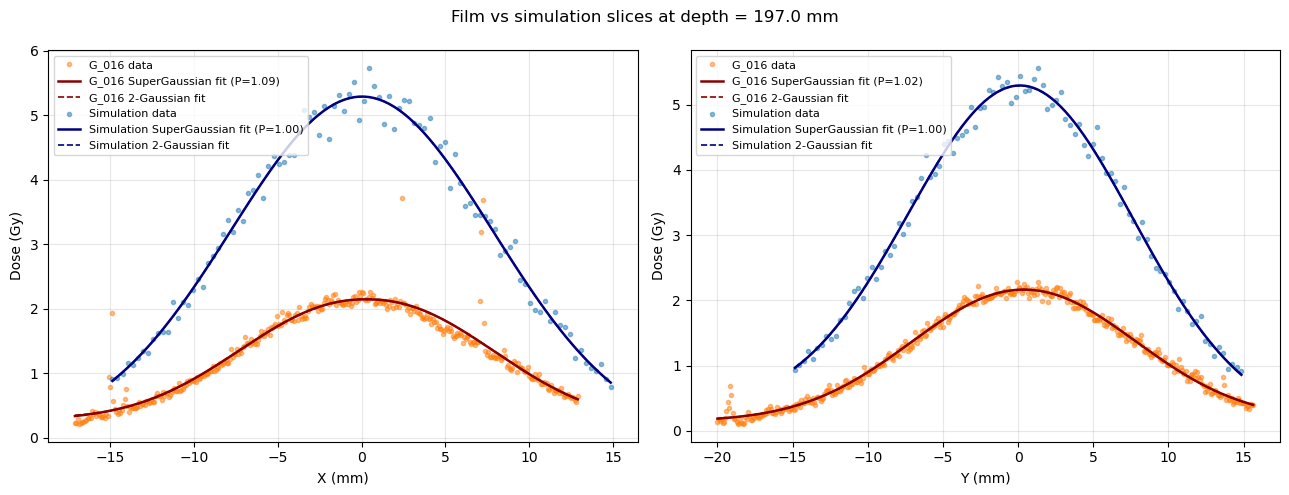

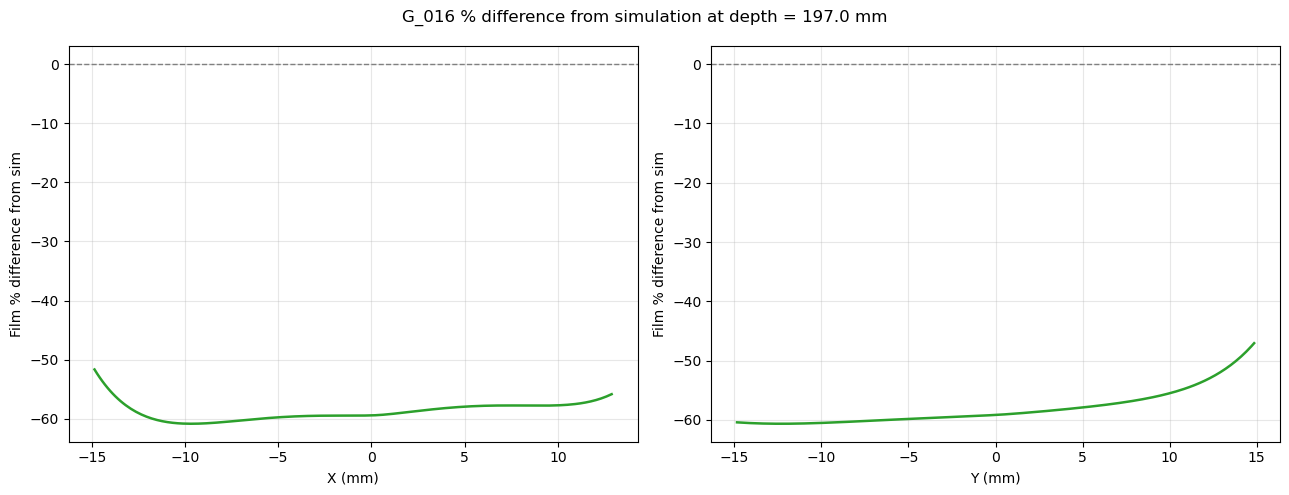

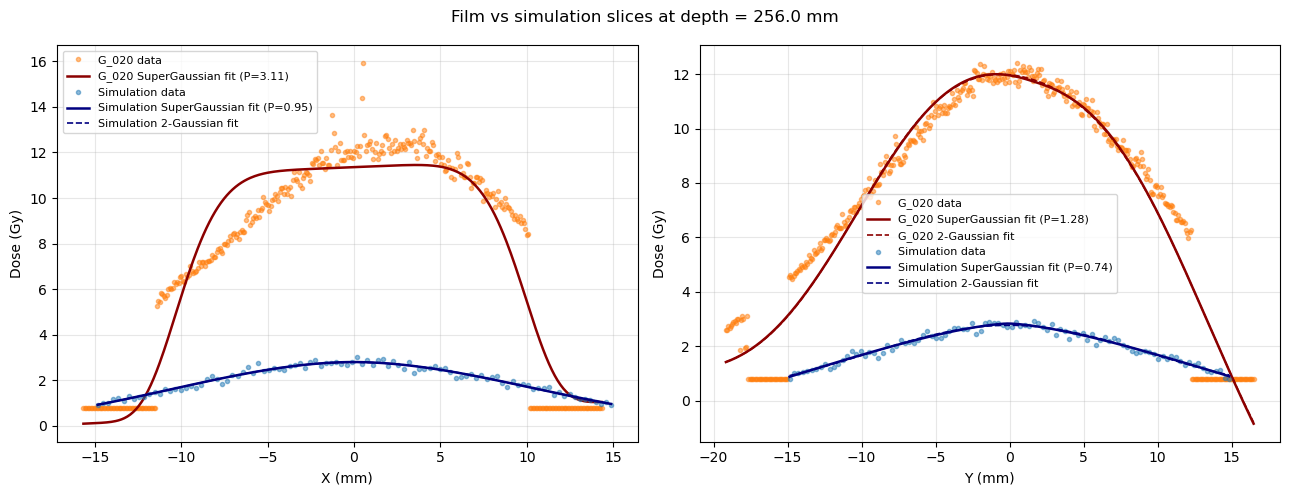

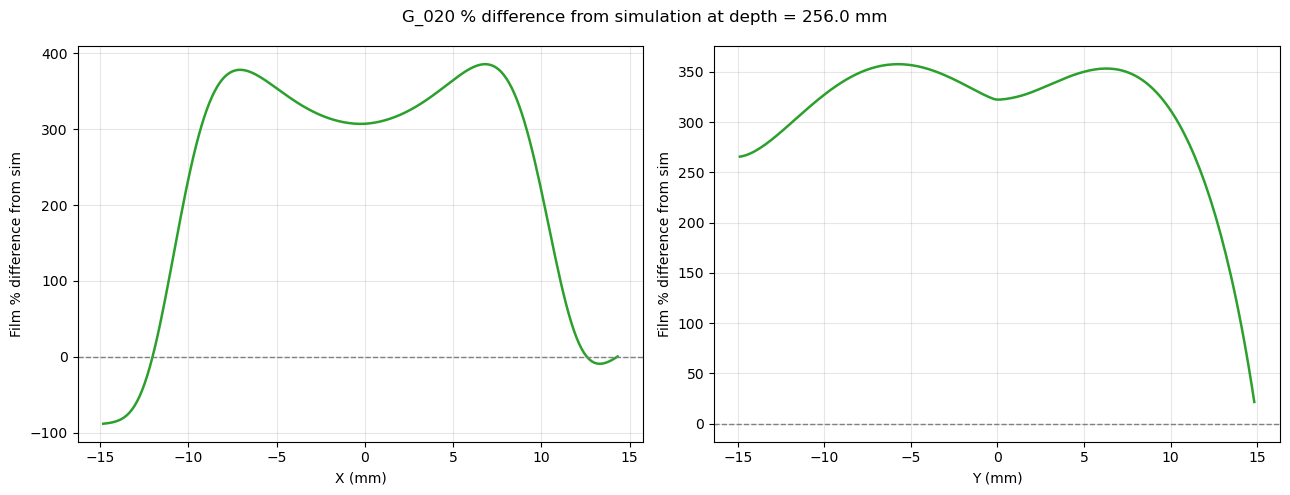

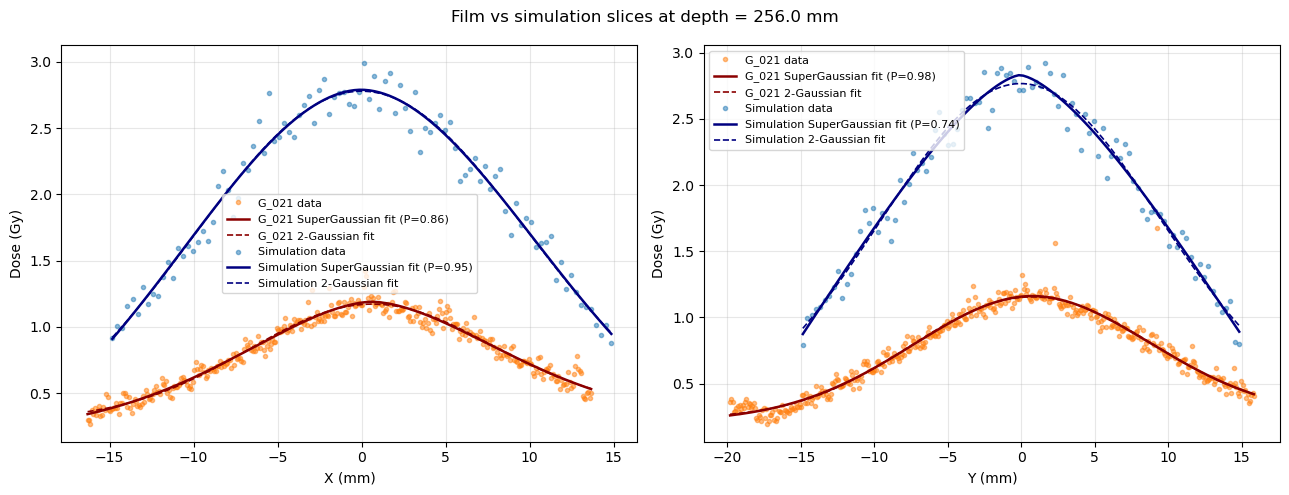

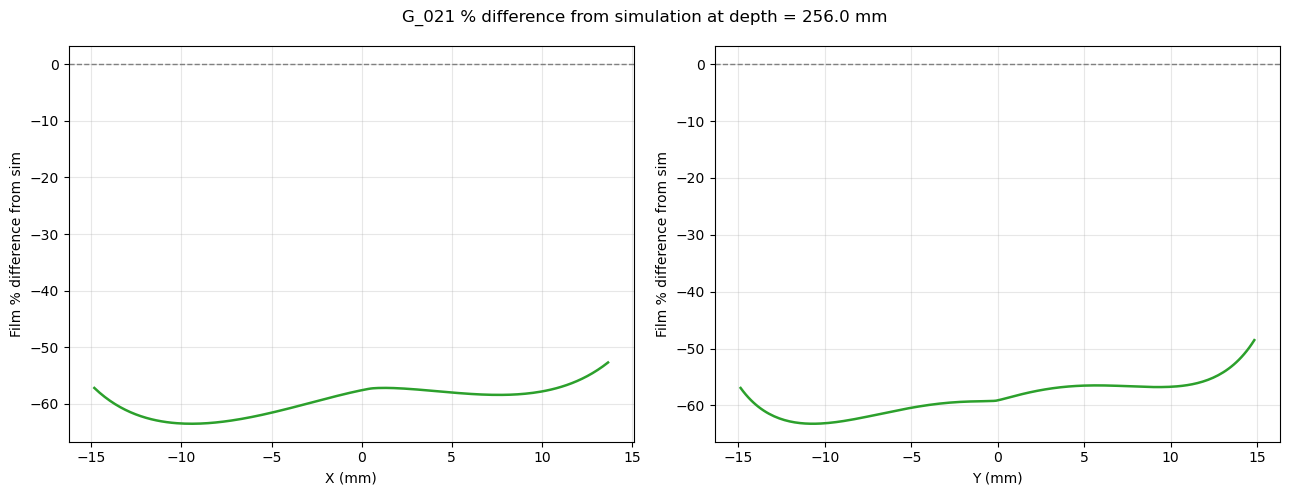

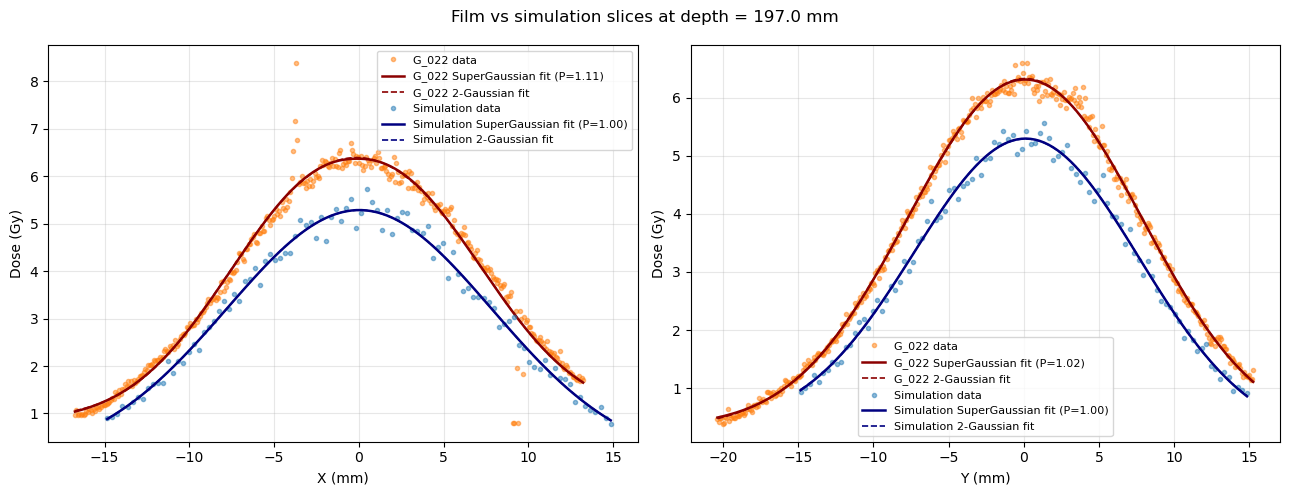

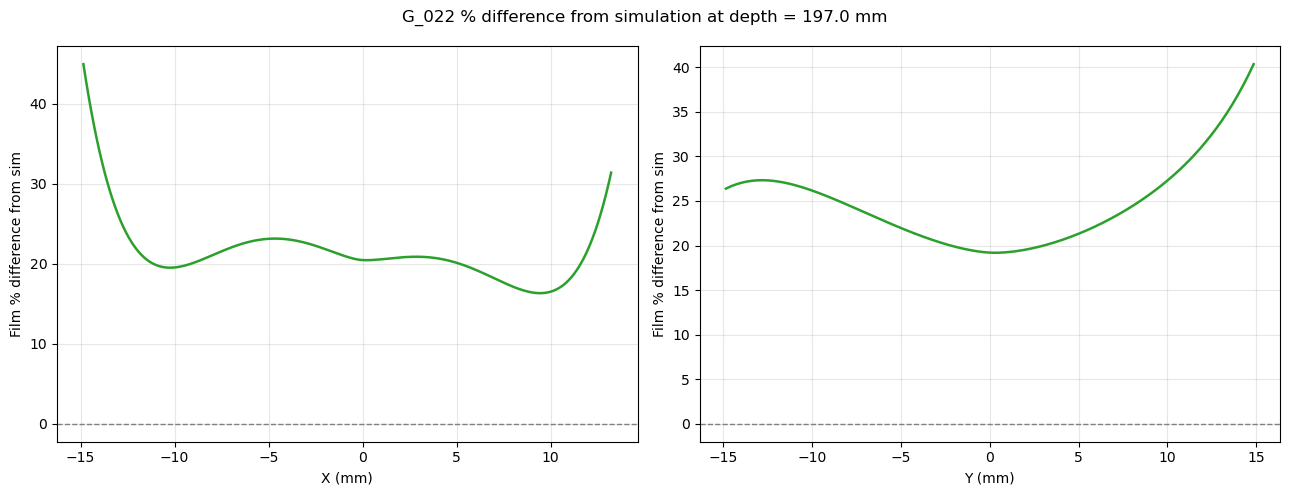

In [59]:
collimated_figs = {}
for film_filename, depth_mm in collimated_film_specs:
    fx, fy, film_dose = load_film_dosemap(film_dir + film_filename + ".tif", channel, OD0)
    sx, sy, sim_dose, matched_depth = load_sim_dosemap(
        dose_file, n_particles, output_filename, chargenC, depth_mm
    )

    film_slices = get_dose_slices(film_dose, fx, fy, strip_width=2)
    sim_slices = get_dose_slices(sim_dose, sx, sy, strip_width=2)

    fig = plot_slice_overlay(film_slices, sim_slices, matched_depth, film_label=film_filename)
    collimated_figs[film_filename] = fig
    plt.show()

    diff_fig = plot_transverse_pct_diff(film_slices, sim_slices, matched_depth, film_label=film_filename)
    plt.show()

G_004  depth=  20.0 mm  film=   2306.88  sim=   1915.10  ratio=0.830
G_008  depth=  79.0 mm  film=   2578.02  sim=   2092.20  ratio=0.812
G_012  depth= 138.0 mm  film=   2578.63  sim=   2104.36  ratio=0.816
G_016  depth= 197.0 mm  film=    780.65  sim=   1841.80  ratio=2.359
G_020  depth= 256.0 mm  film=   5226.24  sim=   1335.66  ratio=0.256
G_021  depth= 256.0 mm  film=    589.55  sim=   1335.66  ratio=2.266
G_022  depth= 197.0 mm  film=   2369.00  sim=   1841.80  ratio=0.777


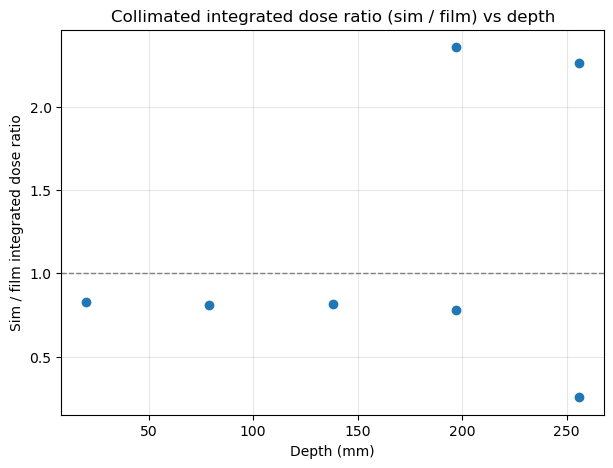

In [60]:
collimated_integrated_rows = []
for film_filename, depth_mm in collimated_film_specs:
    fx, fy, film_dose = load_film_dosemap(film_dir + film_filename + ".tif", channel, OD0)
    sx, sy, sim_dose, matched_depth = load_sim_dosemap(
        dose_file, n_particles, output_filename, chargenC, depth_mm
    )

    film_integrated = integrated_dose(film_dose, fx, fy)
    sim_integrated = integrated_dose(sim_dose, sx, sy)

    collimated_integrated_rows.append({
        "film": film_filename,
        "depth_mm": matched_depth,
        "film_integrated": film_integrated,
        "sim_integrated": sim_integrated,
        "sim_over_film": sim_integrated / film_integrated,
    })

for row in collimated_integrated_rows:
    print(f"{row['film']}  depth={row['depth_mm']:6.1f} mm  "
          f"film={row['film_integrated']:10.2f}  sim={row['sim_integrated']:10.2f}  "
          f"ratio={row['sim_over_film']:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([r["depth_mm"] for r in collimated_integrated_rows], [r["sim_over_film"] for r in collimated_integrated_rows],
        "o", markersize=6)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Depth (mm)")
ax.set_ylabel("Sim / film integrated dose ratio")
ax.set_title("Collimated integrated dose ratio (sim / film) vs depth")
ax.grid(alpha=0.3)
plt.show()